# Module 07: Unsupervised Learning


## Module outline

* **Step 1: Partitioning & Silhouette Analysis**
  * K-Means Clustering: Objective function (Inertia/Within-Cluster Sum of Squares), Lloyd's algorithm, K-Means++ initialization, and local minima issues.
  * Determining Optimal Clusters: Elbow Method (Inertia), Silhouette Coefficient (evaluating separation and cohesion), and Davies-Bouldin Index.
  * K-Medoids (PAM): Robust centroid selection using absolute distances.
* **Step 2: Hierarchical & Density-Based Clustering**
  * Hierarchical Agglomerative Clustering: Bottom-up grouping, linkage criteria (Ward, Single, Complete, Average), and Dendrogram interpretation.
  * DBSCAN (Density-Based Spatial Clustering of Applications with Noise): Core points, Border points, Noise points, epsilon ($\epsilon$), and minimum samples (MinPts) parameter setting.
  * HDBSCAN: Hierarchical density clustering, robust to varying densities, extracting stable clusters.
* **Step 3: Advanced Unsupervised Models**
  * Gaussian Mixture Models (GMM): Soft clustering, generative model assumptions, and parameter optimization via the Expectation-Maximization (EM) algorithm.
  * Clustering Validation: Internal validation (Silhouette) vs. External validation (Adjusted Rand Index - ARI, Normalized Mutual Information - NMI).
  * Anomaly & Novelty Detection: One-Class SVM, Isolation Forest (using path length of random isolation trees), and Local Outlier Factor (LOF).
  * Association Rule Mining: Apriori algorithm, FP-Growth, and evaluation metrics (Support, Confidence, Lift, Conviction).


## Module 7: Unsupervised Learning on a Real 10,000-Record Dataset

This module now uses a real dataset instead of only small toy examples.

Dataset used: **Covertype** from scikit-learn.

- Rows in original dataset: `581,012`
- Rows used in this notebook: `10,000` sampled records
- Features: elevation, slope, distances, hillshade, wilderness area, soil type
- Existing label: `Cover_Type`

Important: unsupervised models do **not** use `Cover_Type` while training. We keep it only for external evaluation after clustering.

This is the correct learning flow:

```text
load real data -> choose features -> scale -> fit one model -> show metrics -> interpret -> decide if result is good or needs correction
```


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.datasets import fetch_covtype
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score
)

plt.rcParams['figure.figsize'] = (7.5, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 10

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'datasets' / 'sklearn_data' / 'covertype' / 'samples_py3').exists()
)
DATA_HOME = (PROJECT_ROOT / 'datasets' / 'sklearn_data').resolve()
covertype = fetch_covtype(data_home=str(DATA_HOME), as_frame=True, download_if_missing=False)
full_df = covertype.frame

# Use 10,000 real records so the notebook remains fast and readable.
df = full_df.sample(n=10_000, random_state=42).reset_index(drop=True)

feature_cols = [c for c in df.columns if c != 'Cover_Type']
X = df[feature_cols]
y_true = df['Cover_Type']

# A smaller numeric subset makes plots and distance-based models easier to understand.
main_features = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]
X_main = df[main_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_main)

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

print('Covertype sample shape:', df.shape)
print('Feature matrix used for most models:', X_main.shape)
print('Cover_Type distribution in the 10k sample:')
display(y_true.value_counts().sort_index().rename('count').to_frame())

display(df[main_features + ['Cover_Type']].head())


Covertype sample shape: (10000, 55)
Feature matrix used for most models: (10000, 10)
Cover_Type distribution in the 10k sample:


,count
Cover_Type,
1,3683
2,4841
3,623
4,47
5,160
6,299
7,347


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type
0,3351.0,206.0,27.0,726.0,124.0,3813.0,192.0,252.0,180.0,2271.0,1
1,2732.0,129.0,7.0,212.0,1.0,1082.0,231.0,236.0,137.0,912.0,2
2,2572.0,24.0,9.0,201.0,25.0,957.0,216.0,222.0,142.0,2191.0,2
3,2824.0,69.0,13.0,417.0,39.0,3223.0,233.0,214.0,110.0,6478.0,2
4,2529.0,84.0,5.0,120.0,9.0,1092.0,227.0,231.0,139.0,4983.0,2


### Dataset Visual Check

Before running clustering, we first look at the data in two PCA components.

PCA is used here only for visualization. The clustering models below still use the scaled feature matrix unless stated otherwise.

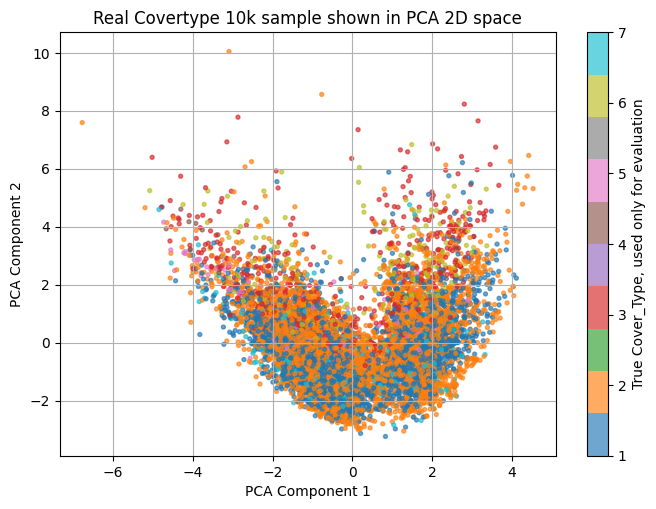

In [2]:
plt.figure(figsize=(8, 5.5))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, cmap='tab10', s=8, alpha=0.65)
plt.title('Real Covertype 10k sample shown in PCA 2D space')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter, label='True Cover_Type, used only for evaluation')
plt.show()


### Metric Helper

For unsupervised learning, metrics are different from supervised accuracy.

Internal metrics do not need true labels:

- **Silhouette:** higher is better; checks cluster separation and cohesion.
- **Davies-Bouldin:** lower is better; checks compactness and separation.

External metrics compare clusters to the known label after training:

- **ARI:** Adjusted Rand Index; higher is better.
- **NMI:** Normalized Mutual Information; higher is better.

We do not train using `Cover_Type`; we only use it to judge whether discovered clusters align with real forest cover classes.

In [3]:
def evaluate_clustering(name, labels, X_for_metric, y_reference=y_true, sample_size=3000):
    labels = np.asarray(labels)
    unique_labels = sorted(set(labels))
    cluster_count = len([x for x in unique_labels if x != -1])
    noise_count = int((labels == -1).sum())

    result = {
        'Model': name,
        'Clusters_found_excluding_noise': cluster_count,
        'Noise_points': noise_count,
        'ARI_vs_Cover_Type': adjusted_rand_score(y_reference, labels),
        'NMI_vs_Cover_Type': normalized_mutual_info_score(y_reference, labels)
    }

    valid_mask = labels != -1
    valid_labels = labels[valid_mask]
    if len(set(valid_labels)) >= 2 and valid_mask.sum() > 20:
        rng = np.random.RandomState(42)
        valid_indices = np.where(valid_mask)[0]
        if len(valid_indices) > sample_size:
            valid_indices = rng.choice(valid_indices, size=sample_size, replace=False)
        result['Silhouette_sample'] = silhouette_score(X_for_metric[valid_indices], labels[valid_indices])
        result['Davies_Bouldin_sample'] = davies_bouldin_score(X_for_metric[valid_indices], labels[valid_indices])
    else:
        result['Silhouette_sample'] = np.nan
        result['Davies_Bouldin_sample'] = np.nan

    return result

metric_rows = []


### Model 1 - K-Means Clustering

K-Means is a strong first baseline for clustering.

- **Use when:** clusters are roughly round and similar-sized.
- **Main hyperparameter:** `k`, the number of clusters.
- **Problem:** if `k` is wrong, the model forces the data into the wrong number of groups.

Because the real Covertype data has 7 cover types, we test several `k` values and compare metrics.

,Model,Clusters_found_excluding_noise,Noise_points,ARI_vs_Cover_Type,NMI_vs_Cover_Type,Silhouette_sample,Davies_Bouldin_sample,Inertia
0,KMeans_k4,4,0,0.025445,0.031904,0.179727,1.614784,63585.279992
1,KMeans_k5,5,0,0.037538,0.051308,0.168760,1.640746,57833.690398
2,KMeans_k6,6,0,0.020844,0.051489,0.170127,1.559991,53284.891627
3,KMeans_k7,7,0,0.026275,0.073729,0.158082,1.611596,50472.788711
4,KMeans_k8,8,0,0.022005,0.068000,0.160691,1.597222,48215.502857
5,KMeans_k10,10,0,0.024490,0.083656,0.147195,1.646999,44895.522013


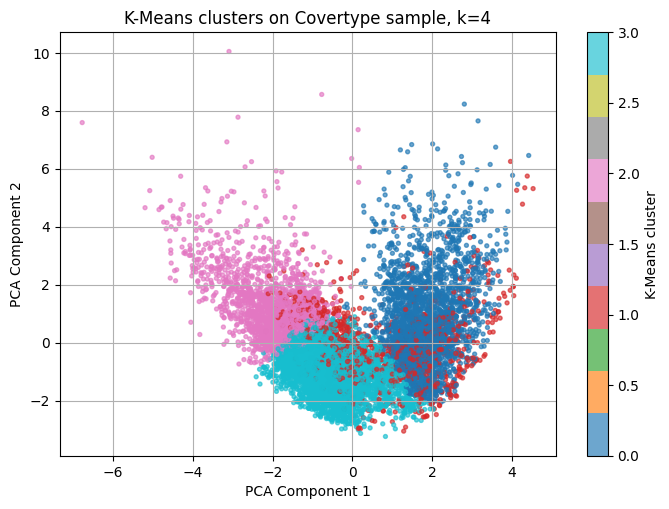

In [4]:
from sklearn.cluster import KMeans

k_rows = []
for k in [4, 5, 6, 7, 8, 10]:
    model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = model.fit_predict(X_scaled)
    eval_row = evaluate_clustering(f'KMeans_k{k}', labels, X_scaled)
    eval_row['Inertia'] = model.inertia_
    k_rows.append(eval_row)

kmeans_metrics = pd.DataFrame(k_rows)
display(kmeans_metrics)

best_k_row = kmeans_metrics.sort_values('Silhouette_sample', ascending=False).iloc[0]
best_k = int(best_k_row['Model'].split('k')[-1])
kmeans = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
metric_rows.append(evaluate_clustering(f'KMeans_best_k{best_k}', kmeans_labels, X_scaled))

plt.figure(figsize=(8, 5.5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_labels, cmap='tab10', s=8, alpha=0.65)
plt.title(f'K-Means clusters on Covertype sample, k={best_k}')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='K-Means cluster')
plt.show()


**How to judge K-Means:**

- If silhouette is low, clusters are not cleanly separated.
- If ARI/NMI are low, K-Means clusters do not match the real cover types well.
- That does not always mean K-Means is ?wrong?; it may mean the real classes are not round distance-based clusters.

If K-Means is weak, we try models that can handle different shapes or soft membership.

### Step 1 Deep Dive - K-Means Objective, Lloyd's Algorithm, K-Means++, Local Minima, and Elbow Method

The outline has several K-Means concepts. They are different and each matters.

#### K-Means objective: inertia / WCSS

K-Means tries to minimize the distance between points and their assigned cluster center.

```text
WCSS = sum of squared distances from each point to its cluster centroid
```

In scikit-learn, this is called **inertia**.

Lower inertia means points are closer to their centroids. But inertia always goes down when `k` increases, so we cannot choose `k` from inertia alone.

#### Lloyd's algorithm

Lloyd's algorithm is the standard K-Means training loop.

```text
1. Choose starting centroids.
2. Assign each point to the nearest centroid.
3. Move each centroid to the mean of its assigned points.
4. Repeat steps 2 and 3 until assignments stop changing or improvement becomes tiny.
```

#### K-Means++ initialization

Random starting centroids can be bad. K-Means++ chooses starting centers more carefully:

```text
first center: choose one point
next centers: prefer points far from existing centers
```

This usually gives better starting centroids and reduces bad local minima.

#### Local minima

K-Means can get stuck in a local minimum. That means it found a solution that cannot improve with small updates, but another starting point might find a better solution.

That is why we use:

```text
n_init > 1
```

It runs K-Means multiple times with different starts and keeps the best inertia.

#### Elbow method

The elbow method plots inertia for different `k` values.

- At first, adding clusters reduces inertia a lot.
- Later, adding clusters only gives small improvement.
- The bend point is the ?elbow?.

The elbow is a guide, not a law. We should compare it with silhouette, Davies-Bouldin, and domain meaning.


Different initializations can reach different inertia values:


,init,seed,inertia_WCSS,iterations_until_stop,silhouette_sample
0,random,0,50473.117178,19,0.161760
3,random,3,50478.292095,36,0.155649
7,k-means++,2,50478.419821,40,0.155446
1,random,1,50478.727765,15,0.155677
5,k-means++,0,50479.500765,28,0.155374
2,random,2,50908.990572,22,0.170185
8,k-means++,3,50909.089791,20,0.170270
4,random,4,50910.573189,44,0.170597
6,k-means++,1,51045.294541,56,0.166082
9,k-means++,4,51047.032103,18,0.158128


,k,inertia_WCSS,silhouette_sample,davies_bouldin_sample
0,2,79841.499142,0.222299,1.797381
1,3,70331.990142,0.180281,1.775609
2,4,63585.279992,0.186061,1.616025
3,5,57833.690398,0.176051,1.622441
4,6,53284.891627,0.176063,1.566462
5,7,50472.788711,0.161338,1.606180
6,8,48215.502857,0.167817,1.594357
7,9,46479.851442,0.154551,1.630725
8,10,44895.522013,0.145120,1.681934
9,11,43246.945270,0.142095,1.651179


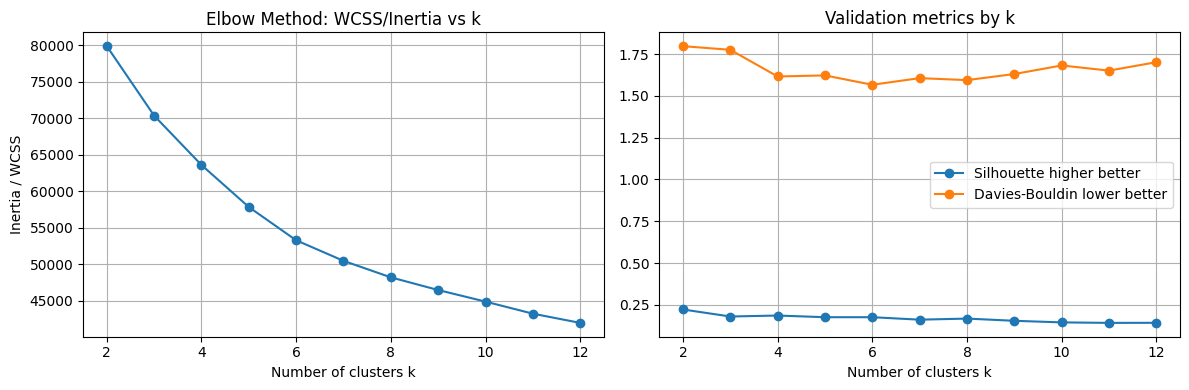

In [5]:
# K-Means mechanics demonstration on the real 10k dataset.
from sklearn.cluster import KMeans

mechanics_rows = []
for init_method in ['random', 'k-means++']:
    for seed in [0, 1, 2, 3, 4]:
        model = KMeans(
            n_clusters=7,
            init=init_method,
            n_init=1,
            random_state=seed,
            max_iter=300
        )
        labels = model.fit_predict(X_scaled)
        mechanics_rows.append({
            'init': init_method,
            'seed': seed,
            'inertia_WCSS': model.inertia_,
            'iterations_until_stop': model.n_iter_,
            'silhouette_sample': silhouette_score(X_scaled[:3000], labels[:3000])
        })

mechanics_df = pd.DataFrame(mechanics_rows)
print('Different initializations can reach different inertia values:')
display(mechanics_df.sort_values('inertia_WCSS'))

elbow_rows = []
for k in range(2, 13):
    model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = model.fit_predict(X_scaled)
    elbow_rows.append({
        'k': k,
        'inertia_WCSS': model.inertia_,
        'silhouette_sample': silhouette_score(X_scaled[:3000], labels[:3000]),
        'davies_bouldin_sample': davies_bouldin_score(X_scaled[:3000], labels[:3000])
    })

elbow_df = pd.DataFrame(elbow_rows)
display(elbow_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(elbow_df['k'], elbow_df['inertia_WCSS'], marker='o')
axes[0].set_title('Elbow Method: WCSS/Inertia vs k')
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Inertia / WCSS')
axes[1].plot(elbow_df['k'], elbow_df['silhouette_sample'], marker='o', label='Silhouette higher better')
axes[1].plot(elbow_df['k'], elbow_df['davies_bouldin_sample'], marker='o', label='Davies-Bouldin lower better')
axes[1].set_title('Validation metrics by k')
axes[1].set_xlabel('Number of clusters k')
axes[1].legend()
plt.tight_layout()
plt.show()


### Model 2 - MiniBatch K-Means

MiniBatch K-Means is a faster version of K-Means.

- **Use when:** dataset is large and full K-Means is slow.
- **Main idea:** update centroids using small batches instead of all rows at once.
- **Tradeoff:** faster, but sometimes a little less exact.

This is useful because real datasets often have far more than 10k rows.

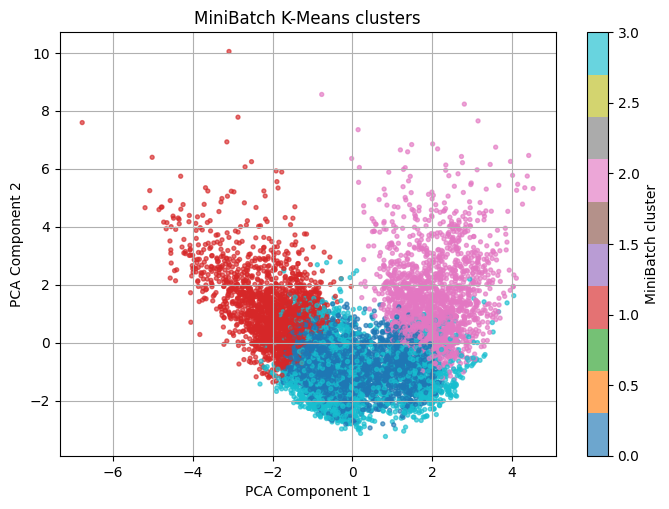

In [6]:
from sklearn.cluster import MiniBatchKMeans

mini = MiniBatchKMeans(n_clusters=best_k, batch_size=512, n_init=10, random_state=42)
mini_labels = mini.fit_predict(X_scaled)
metric_rows.append(evaluate_clustering(f'MiniBatchKMeans_k{best_k}', mini_labels, X_scaled))

plt.figure(figsize=(8, 5.5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=mini_labels, cmap='tab10', s=8, alpha=0.65)
plt.title('MiniBatch K-Means clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='MiniBatch cluster')
plt.show()


### Model 3 - Hierarchical Agglomerative Clustering

Hierarchical clustering can be expensive because it compares many pairs of points.

For this reason, we use a **2,000-record sample** from the 10k dataset.

- **Use when:** we want nested grouping or dendrogram-style structure.
- **Main hyperparameters:** linkage method and number of clusters.
- **Important limitation:** not ideal for very large datasets without sampling or specialized methods.

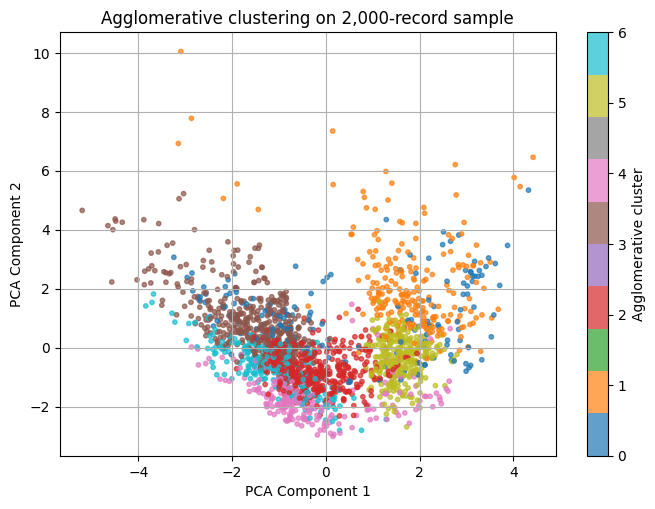

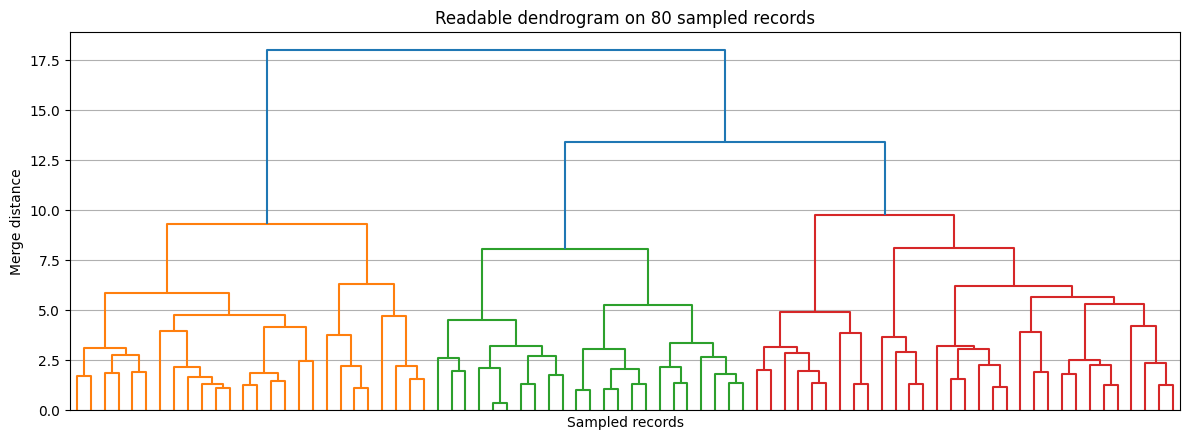

In [7]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

sample_idx = np.random.RandomState(42).choice(len(X_scaled), size=2000, replace=False)
X_hier = X_scaled[sample_idx]
y_hier = y_true.iloc[sample_idx].reset_index(drop=True)
X_hier_2d = X_2d[sample_idx]

hier = AgglomerativeClustering(n_clusters=7, linkage='ward')
hier_labels = hier.fit_predict(X_hier)
metric_rows.append(evaluate_clustering('Agglomerative_Ward_sample2000', hier_labels, X_hier, y_reference=y_hier, sample_size=2000))

plt.figure(figsize=(8, 5.5))
plt.scatter(X_hier_2d[:, 0], X_hier_2d[:, 1], c=hier_labels, cmap='tab10', s=10, alpha=0.7)
plt.title('Agglomerative clustering on 2,000-record sample')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Agglomerative cluster')
plt.show()

# Dendrogram on only 80 rows so it is readable.
dendro_idx = sample_idx[:80]
Z = linkage(X_scaled[dendro_idx], method='ward')
plt.figure(figsize=(12, 4.5))
dendrogram(Z, no_labels=True)
plt.title('Readable dendrogram on 80 sampled records')
plt.xlabel('Sampled records')
plt.ylabel('Merge distance')
plt.tight_layout()
plt.show()


**How to judge hierarchical clustering:**

The scatter plot shows cluster assignment. The dendrogram shows how records merge step by step. If the dendrogram has clear large jumps, those jumps can suggest natural cluster cuts.

Because hierarchical clustering is expensive, the sample size is part of the implementation decision.

### Model 4 - DBSCAN

DBSCAN finds dense regions and marks sparse points as noise.

- **Use when:** clusters are irregularly shaped or there are outliers.
- **Main hyperparameters:** `eps` and `min_samples`.
- **Problem:** if `eps` is too small, many points become noise; if too large, clusters merge.

For Covertype, DBSCAN is run on a 2D PCA representation for speed and visibility. This is a practical teaching choice.

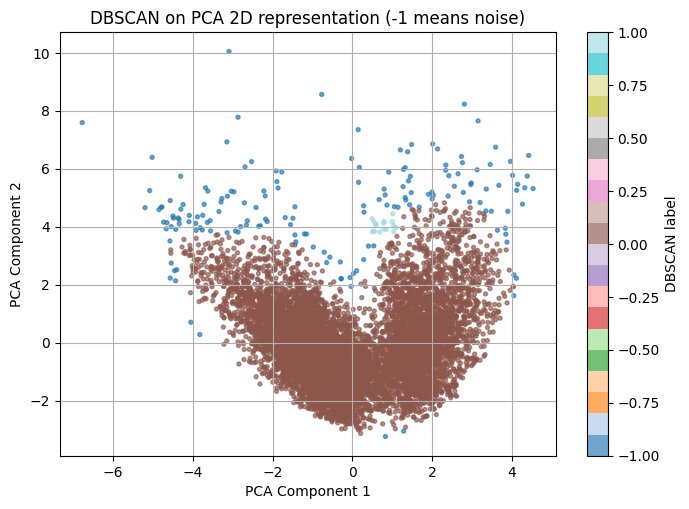

DBSCAN label counts:


,count
-1,168
0,9815
1,17


In [8]:
from sklearn.cluster import DBSCAN

X_db = X_2d
for eps in [0.25, 0.40, 0.60]:
    db = DBSCAN(eps=eps, min_samples=15)
    labels = db.fit_predict(X_db)
    row = evaluate_clustering(f'DBSCAN_eps{eps}', labels, X_db)
    metric_rows.append(row)

# Use eps=0.40 as a middle setting for the visual.
dbscan = DBSCAN(eps=0.40, min_samples=15)
db_labels = dbscan.fit_predict(X_db)

plt.figure(figsize=(8, 5.5))
plt.scatter(X_db[:, 0], X_db[:, 1], c=db_labels, cmap='tab20', s=8, alpha=0.65)
plt.title('DBSCAN on PCA 2D representation (-1 means noise)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='DBSCAN label')
plt.show()

print('DBSCAN label counts:')
display(pd.Series(db_labels).value_counts().sort_index().rename('count').to_frame())


**How to judge DBSCAN:**

Look at both metrics and label counts. If almost everything is noise, `eps` is too small. If everything becomes one cluster, `eps` is too large.

DBSCAN may not align with `Cover_Type` because density clusters and forest-cover labels are different ideas.

### Model 5 - Gaussian Mixture Model (GMM)

GMM gives **soft clustering**.

- **Use when:** groups overlap and we want probabilities.
- **Main hyperparameter:** number of components.
- **Output:** cluster label plus probability for each component.

This is useful when a record is not clearly inside one group.

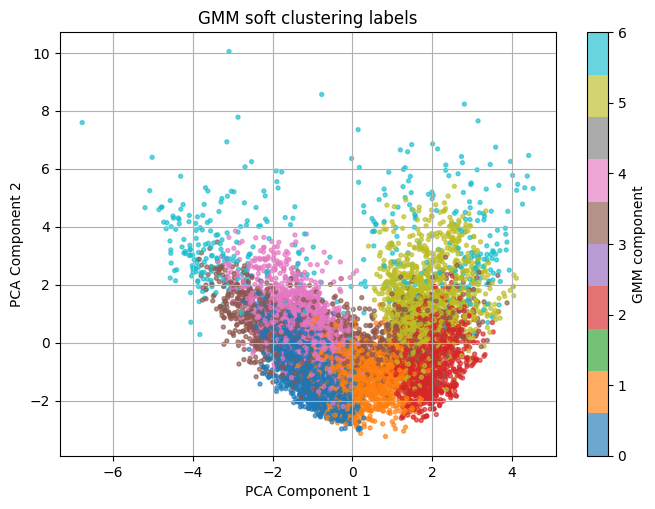

First 10 GMM membership probability examples:


,Component_0,Component_1,Component_2,Component_3,Component_4,Component_5,Component_6,Confidence
0,0.000,0.000,0.000,1.0,0.000,0.0,0.0,1.000
1,0.000,1.000,0.000,0.0,0.000,0.0,0.0,1.000
2,0.000,0.000,0.000,0.0,1.000,0.0,0.0,1.000
3,1.000,0.000,0.000,0.0,0.000,0.0,0.0,1.000
4,1.000,0.000,0.000,0.0,0.000,0.0,0.0,1.000
5,0.000,0.000,0.000,0.0,0.000,0.0,1.0,1.000
6,0.000,0.054,0.946,0.0,0.000,0.0,0.0,0.946
7,0.776,0.224,0.000,0.0,0.000,0.0,0.0,0.776
8,0.000,1.000,0.000,0.0,0.000,0.0,0.0,1.000
9,0.994,0.000,0.000,0.0,0.006,0.0,0.0,0.994


In [9]:
from sklearn.mixture import GaussianMixture

# GMM can be slower on 10k, but it is fine on the 10 numeric features here.
gmm = GaussianMixture(n_components=7, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)
gmm_probs = gmm.predict_proba(X_scaled)
gmm_confidence = gmm_probs.max(axis=1)
metric_rows.append(evaluate_clustering('GMM_components7', gmm_labels, X_scaled))

plt.figure(figsize=(8, 5.5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=gmm_labels, cmap='tab10', s=8, alpha=0.65)
plt.title('GMM soft clustering labels')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='GMM component')
plt.show()

print('First 10 GMM membership probability examples:')
display(pd.DataFrame(gmm_probs[:10].round(3), columns=[f'Component_{i}' for i in range(gmm_probs.shape[1])]).assign(Confidence=gmm_confidence[:10].round(3)))


**How to judge GMM:**

The confidence column matters. If many records have low confidence, the components overlap heavily. That means hard cluster labels may be too simplistic.

### Model 6 - Anomaly Detection

Anomaly detection finds unusual records.

For Covertype, unusual records may be rare terrain combinations, extreme elevation/distance values, or sparse feature combinations.

Models used:

- **Isolation Forest:** isolates unusual rows quickly using random splits.
- **Local Outlier Factor:** compares local density to neighbors.
- **One-Class SVM:** learns a boundary around normal data.

These models do not use `Cover_Type`. They produce anomaly flags.

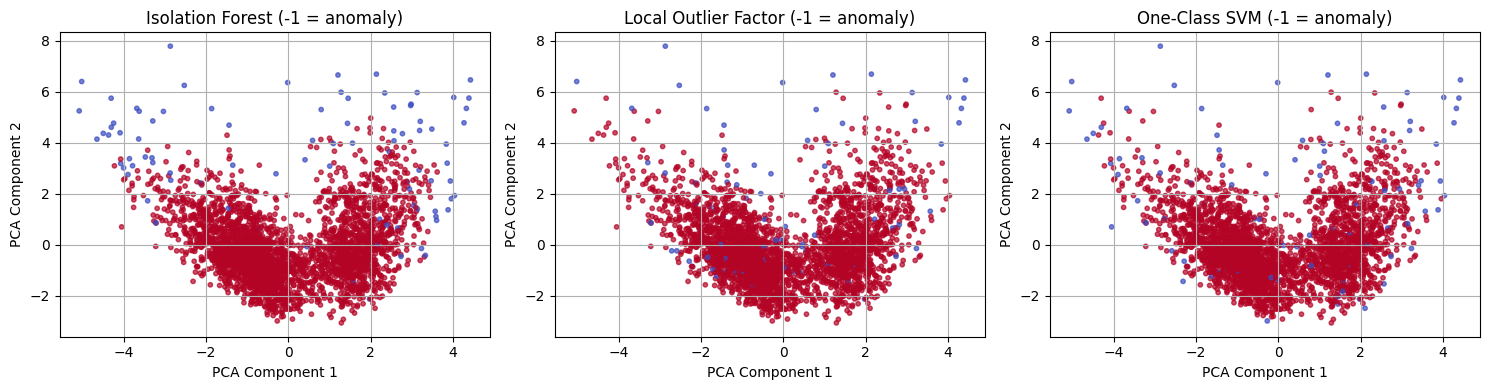

,Model,Anomalies_Found,Sample_Size
0,Isolation Forest,90,3000
1,LOF,90,3000
2,One-Class SVM,95,3000


In [10]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

# Use a 3,000-record sample for LOF and One-Class SVM speed.
anom_idx = np.random.RandomState(7).choice(len(X_scaled), size=3000, replace=False)
X_anom = X_scaled[anom_idx]
X_anom_2d = X_2d[anom_idx]

iso = IsolationForest(contamination=0.03, random_state=42)
lof = LocalOutlierFactor(n_neighbors=25, contamination=0.03)
ocsvm = OneClassSVM(nu=0.03, gamma='scale')

iso_label = iso.fit_predict(X_anom)
lof_label = lof.fit_predict(X_anom)
ocsvm_label = ocsvm.fit_predict(X_anom)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, labels, title in zip(
    axes,
    [iso_label, lof_label, ocsvm_label],
    ['Isolation Forest', 'Local Outlier Factor', 'One-Class SVM']
):
    ax.scatter(X_anom_2d[:, 0], X_anom_2d[:, 1], c=labels, cmap='coolwarm', s=10, alpha=0.7)
    ax.set_title(title + ' (-1 = anomaly)')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

anom_summary = pd.DataFrame({
    'Model': ['Isolation Forest', 'LOF', 'One-Class SVM'],
    'Anomalies_Found': [(iso_label == -1).sum(), (lof_label == -1).sum(), (ocsvm_label == -1).sum()],
    'Sample_Size': [len(X_anom)] * 3
})
display(anom_summary)


**How to judge anomaly detection:**

There is no single accuracy score unless we have confirmed anomaly labels. Here we judge by anomaly count, location in the plot, and domain reasonableness.

If the model flags too many normal-looking rows, reduce contamination or adjust the method. If it flags nothing, increase sensitivity.

### Model 7 - Association Rule Mining

Association rules need transaction data. Covertype is not a shopping basket dataset, but we can convert each forest record into a transaction by binning features.

Example transaction:

```text
Elevation=High, Slope=Low, Wilderness_Area_0, Cover_Type_2
```

For unsupervised association rules, we normally should not include the target label. Here we create rules from terrain feature bins only, then read which feature combinations commonly occur together.

Metrics:

- **Support:** how often the itemset appears.
- **Confidence:** how often conclusion appears when condition appears.
- **Lift:** whether the rule is stronger than random chance.
- **Conviction:** implication strength.

Apriori and FP-Growth are full algorithms for mining frequent itemsets. Here we implement a small pair-rule version to show the metric meanings without adding another library.

In [11]:
# Build 10k transactions from real Covertype feature bins.
trans_df = df[['Elevation', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways']].copy()
trans_df['Elevation_Bin'] = pd.qcut(trans_df['Elevation'], q=4, labels=['Elev_Q1', 'Elev_Q2', 'Elev_Q3', 'Elev_Q4'])
trans_df['Slope_Bin'] = pd.qcut(trans_df['Slope'], q=4, labels=['Slope_Q1', 'Slope_Q2', 'Slope_Q3', 'Slope_Q4'], duplicates='drop')
trans_df['Hydrology_Distance_Bin'] = pd.qcut(trans_df['Horizontal_Distance_To_Hydrology'], q=4, labels=['Hydro_Q1', 'Hydro_Q2', 'Hydro_Q3', 'Hydro_Q4'], duplicates='drop')
trans_df['Road_Distance_Bin'] = pd.qcut(trans_df['Horizontal_Distance_To_Roadways'], q=4, labels=['Road_Q1', 'Road_Q2', 'Road_Q3', 'Road_Q4'], duplicates='drop')

transactions = trans_df[['Elevation_Bin', 'Slope_Bin', 'Hydrology_Distance_Bin', 'Road_Distance_Bin']].astype(str).agg(set, axis=1).tolist()
items = sorted(set().union(*transactions))

def support(itemset):
    itemset = set(itemset)
    return sum(itemset.issubset(t) for t in transactions) / len(transactions)

rules = []
for a in items:
    for b in items:
        if a == b:
            continue
        sup_ab = support({a, b})
        if sup_ab < 0.06:
            continue
        conf = sup_ab / support({a})
        lift = conf / support({b})
        conviction = (1 - support({b})) / (1 - conf) if conf < 1 else np.inf
        rules.append({
            'Rule': f'{a} -> {b}',
            'Support': round(sup_ab, 3),
            'Confidence': round(conf, 3),
            'Lift': round(lift, 3),
            'Conviction': round(conviction, 3) if np.isfinite(conviction) else 'inf'
        })

rules_df = pd.DataFrame(rules).sort_values(['Lift', 'Confidence'], ascending=False)
display(rules_df.head(15))


,Rule,Support,Confidence,Lift,Conviction
2,Elev_Q1 -> Road_Q1,0.114,0.455,1.818,1.375
52,Road_Q1 -> Elev_Q1,0.114,0.455,1.818,1.375
46,Hydro_Q4 -> Elev_Q4,0.103,0.414,1.658,1.281
19,Elev_Q4 -> Hydro_Q4,0.103,0.413,1.658,1.279
99,Slope_Q4 -> Elev_Q1,0.093,0.378,1.511,1.205
4,Elev_Q1 -> Slope_Q4,0.093,0.370,1.511,1.199
0,Elev_Q1 -> Hydro_Q1,0.095,0.379,1.411,1.178
25,Hydro_Q1 -> Elev_Q1,0.095,0.353,1.411,1.159
3,Elev_Q1 -> Road_Q2,0.086,0.346,1.384,1.147
58,Road_Q2 -> Elev_Q1,0.086,0.346,1.384,1.147


**How to judge association rules:**

High confidence alone is not enough. A rule can have high confidence just because the conclusion item is common. Lift helps check whether the relationship is stronger than chance.

This section uses a real 10k-record dataset, but converts numerical records into transactions because association rules require transaction-style data.

### Step 3 Deep Dive - Internal vs External Clustering Validation

Clustering has two kinds of evaluation.

#### Internal validation

Internal validation uses only the feature matrix and cluster labels.

Examples:

- **Silhouette:** Are points closer to their own cluster than to other clusters?
- **Davies-Bouldin:** Are clusters compact and separated?

Internal validation is useful when there is no true label.

#### External validation

External validation compares discovered clusters to a known reference label.

Examples:

- **ARI: Adjusted Rand Index** compares pairwise agreement between cluster labels and true labels.
- **NMI: Normalized Mutual Information** checks how much information cluster labels share with true labels.

In this module, `Cover_Type` is used only after clustering for external evaluation. The clustering models do not train on it.

#### Correct interpretation

A low ARI/NMI does not always mean the clustering model failed. It can mean:

- the true label is not naturally cluster-shaped
- the selected features do not separate that label
- the algorithm assumptions do not match the data shape
- the chosen hyperparameters need correction


### Final Model Comparison

This table compares clustering models that produce cluster labels. Use it to decide whether the model result looks acceptable or needs correction.

Remember:

- High silhouette is good.
- Low Davies-Bouldin is good.
- High ARI/NMI means clusters align better with known `Cover_Type`, even though the label was not used during training.


In [12]:
comparison_df = pd.DataFrame(metric_rows)
# Sort by NMI and silhouette because this is an exploratory clustering lesson.
display(comparison_df.sort_values(['NMI_vs_Cover_Type', 'Silhouette_sample'], ascending=False))


,Model,Clusters_found_excluding_noise,Noise_points,ARI_vs_Cover_Type,NMI_vs_Cover_Type,Silhouette_sample,Davies_Bouldin_sample
2,Agglomerative_Ward_sample2000,7,0,0.013411,0.068851,0.100725,1.847411
1,MiniBatchKMeans_k4,4,0,0.016730,0.036011,0.145439,1.817410
3,DBSCAN_eps0.25,1,464,0.041424,0.034123,NaN,NaN
0,KMeans_best_k4,4,0,0.025445,0.031904,0.179727,1.614784
6,GMM_components7,7,0,0.012618,0.025439,0.038645,2.692287
4,DBSCAN_eps0.4,2,168,0.021202,0.023297,0.401696,0.480387
5,DBSCAN_eps0.6,1,70,0.007835,0.010558,NaN,NaN
